# Estimating Mutual Information from Data: a comparative analysis of existing methods.

References:
-  "A Statistical Framework for Neuroimaging data Analysis Based on Mutual Information Estimated via a Gaussian Copula"
- [Finite Sample bias correction (Miller-Madow) for Discrete Shannon Entropy](https://arxiv.org/abs/cond-mat/0403192)

Comments:

-   Some functions are written in Numba, a function compiler for accellerating Python code.
    If you do not have it installed, you can get it with:


    ```{bash}
    pip install numba
    ```


In [8]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import scipy
from kneed import KneeLocator


# Our package
import neuro_lib as nlib



# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)


relations_dict = {"linear": lambda s: s,
                "tanh": lambda s: np.tanh(5*s),
                "quadratic": lambda s: 2 * s**2 - 1}

# **SIMULATED DATA**
1) Simulate an external signal $S(t)$ and a neural variable $X(t)$ with three different types of relation with or without lag. 

    Types: 
    - linear
    - monotonic non linear
    - non monotonic (quadratic for example)
 
2) Compute MI (with or without lag, and maybe conditioning on $X(t-1)$) with different methods. 
    
    Methods: 
    - Gaussian (assuming joint normality)
    - Binning 
    - KDE ** maybe ** 
    - Gaussian copula 


    **Gaussian channel**: 

$$
X = f(S) + \sigma \cdot \eta = Z + \sigma \cdot \eta
$$  

- Z: sent variable
- X: received variable
- $\eta$: gaussian white noise (mean = 0, std = 1)
- $\sigma$: channel noise amplitude

# No lag, no temporal structure: simplest case

We start simple. In this section we simulate data without temporal structure, meaning that the source variable $S(t)$ is identically independently distributed at each time step. At this stage, we just want to set up the code for estimating mi and compare the accuracy of the various estimators. 


We will benchmark various estimators with respect to the *true* value of the differential mutual information. Except for a few special cases, the true value is computed numerically. In order to simplify calculations, we assume that the source variable S is *gaussian*:

$$
S \sim \mathcal{N}(0, 1)
$$


--------------

Special case: linear relation $X = S + \sigma \cdot \eta$

$$
S \sim \mathcal{N}(m, v^2),\quad  \eta \sim \mathcal{N}(0, 1), \quad X = S + \sigma \cdot \eta
$$

$$
mi(X:S)= \frac{1}{2}\log_2\left( 1 + \frac{v^2}{\sigma^2}\right)
$$

--------------

General case: $X = f(S) + \sigma \cdot \eta$

$$
mi(X:S) = h(X) - h(X|S) = h(x) - \frac{1}{2}\log_2[2\pi e \sigma^2]
$$

To approximate h(X):

1. generate a large number of X samples (e.g. $N = 1000$)
2. Use KDE to estimate the pdf of X, p
3. Approximate the expectation value with the sample mean $h(x) =\mathbb{E}[- \log_2(p(x))] \simeq \frac{1}{N} \sum \log_2[p(x_i)]$

**Gaussian case: comparison of the analytical mi and the numeric mi (correctness check)**

entropy analytic: 2.547095585180641
entropy numeric: 2.556511804873843
mi analytic: 0.5
mi numeric: 0.5094162196932022


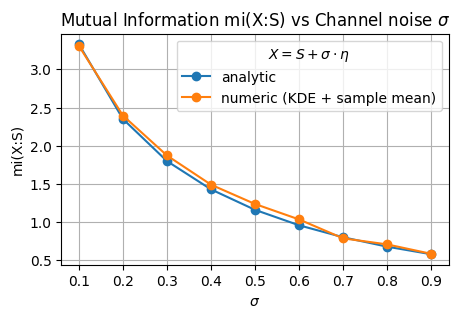

In [10]:
sigma_ = 1
numeric_hx = nlib.entropy_numeric(lambda s: s, sigma=sigma_)


print("entropy analytic:", nlib.entropy_gaussian(np.sqrt(sigma_**2 + 1)))
print("entropy numeric:", numeric_hx)


numeric_mi = numeric_hx - nlib.entropy_gaussian(sigma_)

print("mi analytic:", nlib.mi_gaussian_analytic(sigma_**2))
print("mi numeric:", numeric_mi)



sigma_vec = np.arange(0.1, 1, 0.1)
numeric_mi = [nlib.entropy_numeric(lambda s: s, sigma=sigma) - nlib.entropy_gaussian(sigma) for sigma in sigma_vec]
analytic_mi = [nlib.mi_gaussian_analytic(sigma**2) for sigma in sigma_vec]

fig ,ax = plt.subplots(figsize = (5, 3))
ax.plot(sigma_vec, analytic_mi, marker = "o",  label = "analytic")
ax.plot(sigma_vec, numeric_mi, marker = "o", label = "numeric (KDE + sample mean)")
ax.grid()
ax.legend(title = r"$X = S + \sigma \cdot \eta$")
ax.set_title(r"Mutual Information mi(X:S) vs Channel noise $\sigma$")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("mi(X:S)")
plt.show()


Text(0, 0.5, 'mi(X:S)')

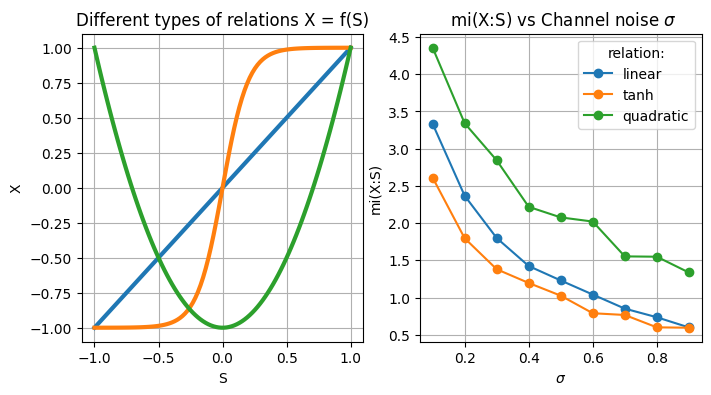

In [11]:
S = np.linspace(-1, +1, 100)


mi_trends = []
for key, f in relations_dict.items():
   mi_trends.append([nlib.entropy_numeric(f, sigma=sigma) - nlib.entropy_gaussian(sigma) for sigma in sigma_vec])



X = np.vstack([nlib.generate_neural_variable(S, f = relations_dict["linear"], noise_std = 0),
            nlib.generate_neural_variable(S, f = relations_dict["tanh"], noise_std = 0),
            nlib.generate_neural_variable(S, f = relations_dict["quadratic"], noise_std = 0)])


fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))

for i, key in enumerate(relations_dict.keys()):
    axs[0].plot(S, X[i, :], label = key, lw = 3)
    axs[1].plot(sigma_vec, mi_trends[i], marker = "o", label = key)

axs[0].set_xlabel("S")
axs[0].set_ylabel("X")
axs[0].set_title("Different types of relations X = f(S)")
axs[0].grid()

axs[1].grid()
axs[1].legend(title = "relation:")
axs[1].set_title(r" mi(X:S) vs Channel noise $\sigma$")
axs[1].set_xlabel(r"$\sigma$")
axs[1].set_ylabel("mi(X:S)")

**Examples of joint scatterplots**

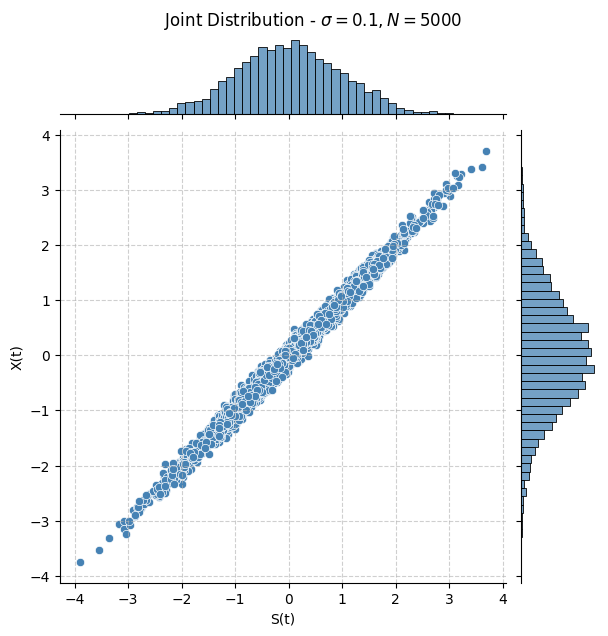

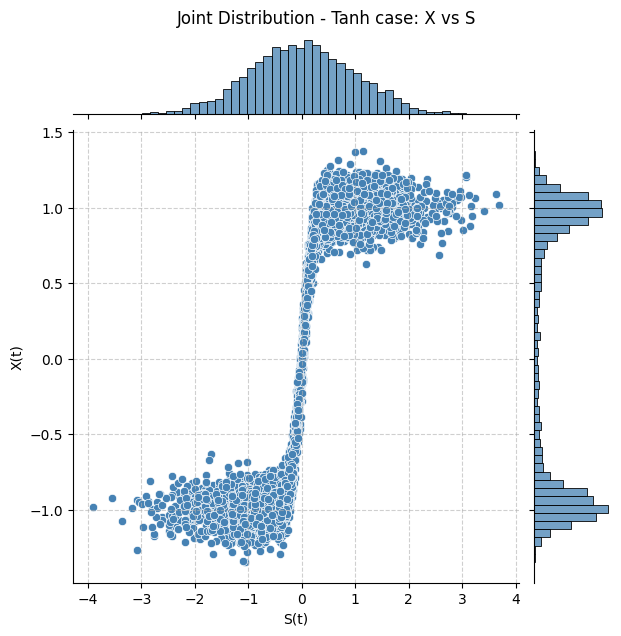

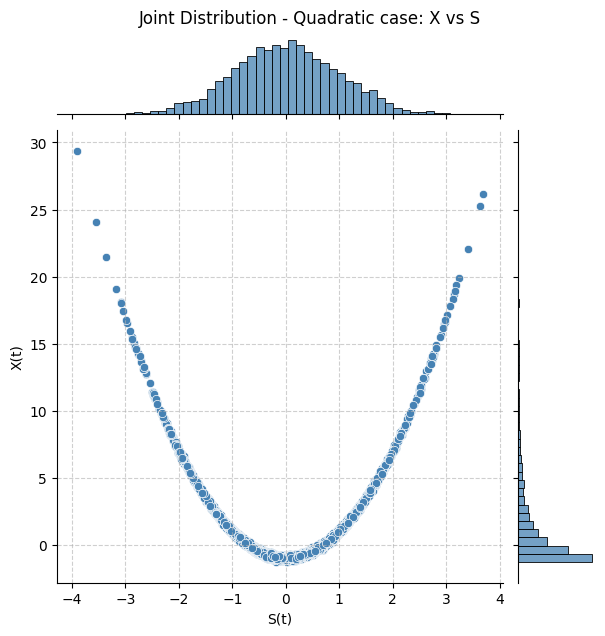

In [12]:
Ntsteps = 5000  # number of samples
sigma_ = 0.1    # channel noise
S = np.random.normal(0, 1, Ntsteps)

X_linear = nlib.generate_neural_variable(S, f= lambda s: s, noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_linear, title_string = rf"$\sigma = {sigma_}, N = {Ntsteps}$")


X_tanh = nlib.generate_neural_variable(S, f= lambda s: np.tanh(5*s), noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_tanh, title_string = "Tanh case: X vs S")

X_quad = nlib.generate_neural_variable(S, lambda s: 2*s**2 - 1, noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_quad, title_string = "Quadratic case: X vs S")

## BINNING METHOD


If X, S are the continuous r.v.s and $X_\epsilon, S_\epsilon$ are their discretized (binned) versions,

$$
lim_{\epsilon \rightarrow 0^+} MI(X_{\epsilon}: S_{\epsilon}) = mi(X, S)
$$


Leaving aside the problem posed by the *curse of dimensionality*, the binning method has some challenges even in the simplest, 2d case:

1. **Bin Number choice**
    - too few bins -> the discretized MI is not a good approximation of the differential mi
    - too many bins -> we are fitting noise


    How do we understand if the bin choice is good, considered that, in practice, we usually have a single data sample, of fixed (possibly low) size?

2. **Uncertainty Estimation**
    Given that the estimate of mi contains dependence on the dataset, can we associate a measure of statistical uncertainty to it?

    A possibility is to do **bootstrapping**: 
    - draw $n<N$ samples from the dataset (with replacement)
    - estimate the mi
    - repeat for a large number of times
    - compute the empirical standard deviation

    But it is not really satisfactory

### Choosing the optimal number of bins

In [15]:
from neuro_lib.core import mi_binning_2d_numba, histogram_error_numba

In [16]:
# ------ Linear case f(s)= s --------------
sigma_ = 0.1
ground_truth_mi = nlib.mi_gaussian_analytic(sigma_**2)
N = 1000
M = 10

bins = np.arange(10, 500, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin)

avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)

# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'


kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")
#kn.plot_knee()

Optimal number of bins: (62, 26)


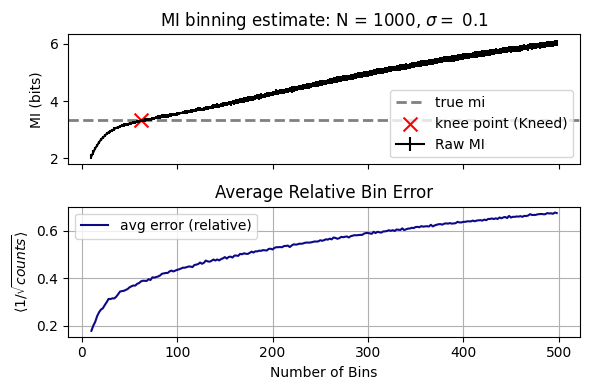

In [17]:
colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

*Empirical observation*: the true value of m.i. seems to corresponds to a knee point of the mi estimate obtained through binning -> This could be a possible cryterion for choosing the optimal bin number.

Let us now systematically check how this cryterion performs, at varying sample size (N) and channel noise ($\sigma$).

In [18]:
sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))
true_mi_vec = np.array([nlib.mi_gaussian_analytic(s**2) for s in sigma_vec])


for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = nlib.generate_data(N, sigma)
            estimates[i, j, k] = nlib.estimate_mi(data, method = "binning", bins = bins)


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])

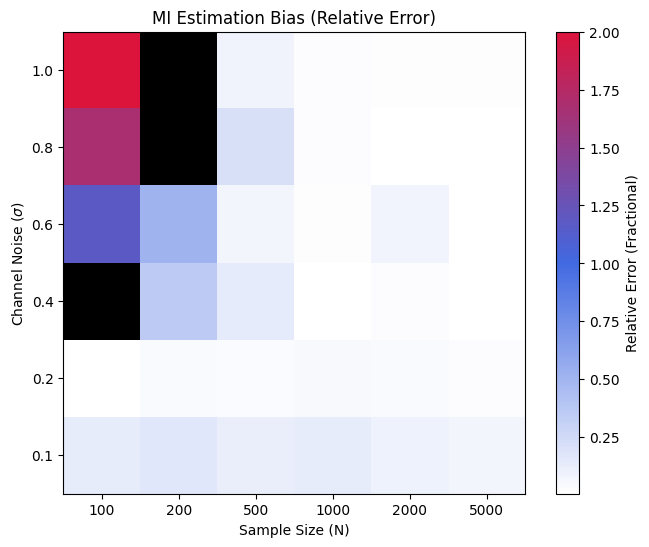

In [20]:
colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")

fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel(r"Channel Noise ($\sigma$)")
ax.set_title("MI Estimation Bias (Relative Error)")

plt.show()

Works pretty well... but will it work also for other kind of relationships f(S)?

Optimal number of bins: (28, 9)


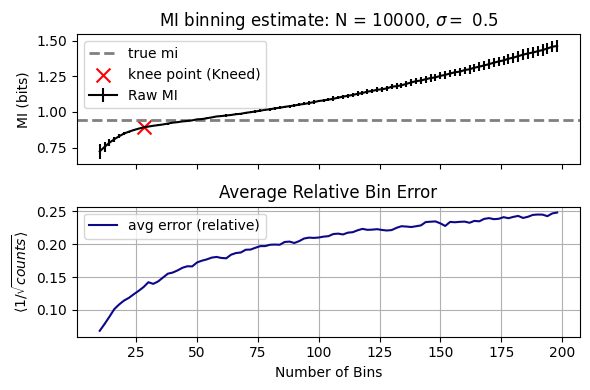

In [21]:
# ---- Function: tanh -----------
f = relations_dict["tanh"]

sigma_ = 0.5
ground_truth_mi = nlib.mi_numeric(f, N_large = 10000, sigma = sigma_)

N = 10000
M = 10

bins = np.arange(10, 200, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_, f)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()



colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

More or less...

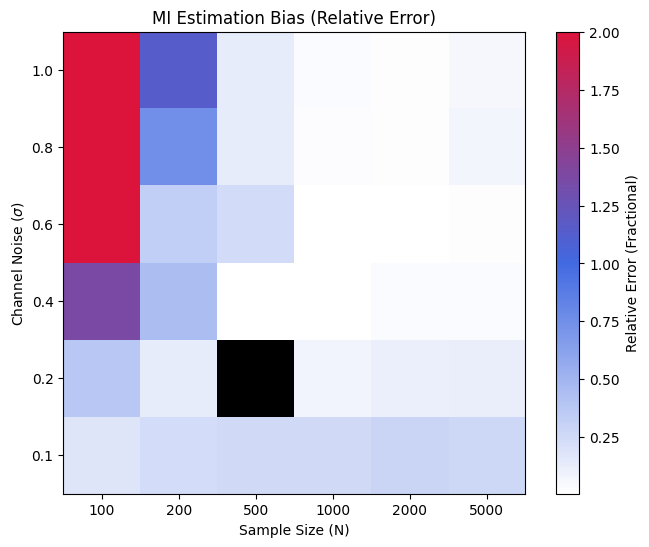

In [22]:
f = relations_dict["tanh"]

sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))
true_mi_vec = np.array([nlib.mi_numeric(f, N_large = 10000, sigma = s) for s in sigma_vec])

# ---------------
for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = nlib.generate_data(N, sigma, f)
            estimates[i, j, k] = nlib.estimate_mi(data, method = "binning", bins = bins)
            


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])


colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")



fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel(r"Channel Noise ($\sigma$)")
ax.set_title("MI Estimation Bias (Relative Error)")

plt.show()

## KDE METHOD
Now let's change method. Given that the differential mutual information can be written as:

$$
mi(X:S) = \int \,dx\,ds \,\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}  \cdot f(s, x) \equiv \mathbb{E}[\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}]
$$
We could use KDE to estimate the (joint, marginal) pdfs, and then approximate shannon entropy with the sample mean
$$
mi(X:S) = \mathbb{E}[\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}] \simeq \frac{1}{N}\, \sum_i \log_2\left[\frac{f(s_i, x_i)}{f(s_i)\cdot f(x_i)}\right]
$$

In [24]:
# --- Linear case ---
N = 1000
sigma_ = 0.1
data = nlib.generate_data(N, sigma_)
true_mi = nlib.mi_gaussian_analytic(sigma_**2)

print("Analytical MI:" , true_mi)
print("KDE estimated MI:" , nlib.estimate_mi(data, method = "kde"))

Analytical MI: 3.3291057413758973
KDE estimated MI: 3.2707607852433083


In [25]:
# Performance at varying N - linear case

N_vec = np.floor(np.logspace(5, 10, base = 2)).astype(int)
sigma_ = 0.1
M = 10
true_mi = nlib.mi_gaussian_analytic(sigma_**2)

binning_estimates = np.empty(shape = (len(N_vec), M))
kde_estimates = np.empty(shape = (len(N_vec), M))

for i, N in enumerate(N_vec):
    for realization in range(M):
        data = nlib.generate_data(N, sigma_)
        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)

        # KDE estimates
        kde_estimates[i, realization] = nlib.estimate_mi(data, method = "kde")

        # Binning estimates
        binning_estimates[i, realization] = nlib.estimate_mi(data, method = "binning", bins=bins)

Text(0.5, 1.0, '$X = S + \\sigma \\cdot \\eta$')

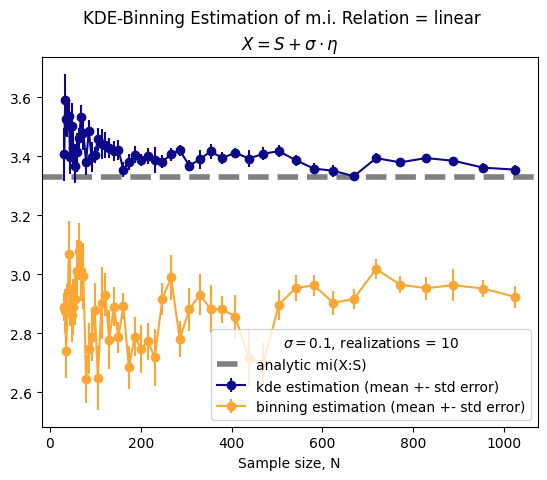

In [26]:
mean_kde = np.mean(kde_estimates, axis = 1)
std_error_kde = np.std(kde_estimates, axis = 1)/np.sqrt(M)

mean_binning = np.mean(binning_estimates, axis = 1)
std_error_binning = np.std(binning_estimates, axis = 1)/np.sqrt(M)

colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "kde": colors[0],
    "binning": colors[1]
}


fig, ax = plt.subplots()
ax.axhline(true_mi, color = "grey", linestyle = "dashed", linewidth = 4, label = "analytic mi(X:S)")
ax.errorbar(N_vec, mean_kde, std_error_kde, color = color_dict["kde"], marker = "o", label = "kde estimation (mean +- std error)")
ax.errorbar(N_vec, mean_binning, std_error_binning, color = color_dict["binning"], marker = "o", label = "binning estimation (mean +- std error)")

ax.legend(title = fr"$\sigma = ${sigma_}, realizations = {M}")
ax.set_xlabel("Sample size, N")
plt.suptitle("KDE-Binning Estimation of m.i. Relation = linear")
ax.set_title(r"$X = S + \sigma \cdot \eta$")

Text(0.5, 1.0, '$X = \\tanh(5\\cdot S) + \\sigma \\cdot \\eta$')

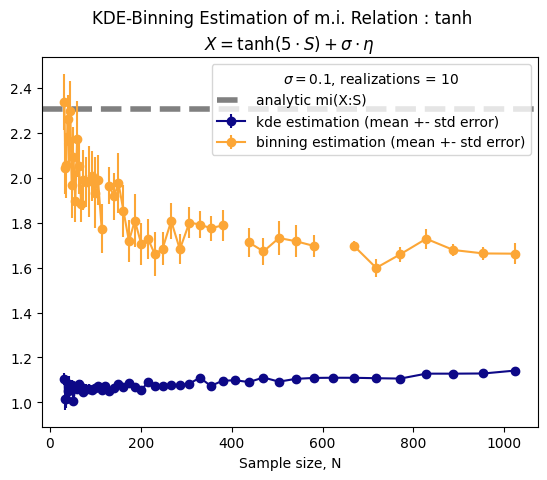

In [27]:
# Performance at varying N  ---- Function: tanh -----------
f = relations_dict["tanh"]
N_vec = np.floor(np.logspace(5, 10, base = 2)).astype(int)
sigma_ = 0.1
M = 10
ground_truth_mi = nlib.mi_numeric(f, N_large = 10000, sigma = sigma_)


binning_estimates = np.empty(shape = (len(N_vec), M))
kde_estimates = np.empty(shape = (len(N_vec), M))

for i, N in enumerate(N_vec):
    for realization in range(M):
        data = nlib.generate_data(N, sigma_, f = f)

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)

        kde_estimates[i, realization] = nlib.estimate_mi(data, method = "kde")
        binning_estimates[i, realization] = nlib.estimate_mi(data, method = "binning", bins = bins)


mean_kde = np.mean(kde_estimates, axis = 1)
std_error_kde = np.std(kde_estimates, axis = 1)/np.sqrt(M)

mean_binning = np.mean(binning_estimates, axis = 1)
std_error_binning = np.std(binning_estimates, axis = 1)/np.sqrt(M)


colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "kde": colors[0],
    "binning": colors[1]
}

fig, ax = plt.subplots()
ax.axhline(ground_truth_mi, color = "grey", linestyle = "dashed", linewidth = 4, label = "analytic mi(X:S)")
ax.errorbar(N_vec, mean_kde, std_error_kde, color = color_dict["kde"], marker = "o", label = "kde estimation (mean +- std error)")
ax.errorbar(N_vec, mean_binning, std_error_binning, color = color_dict["binning"], marker = "o", label = "binning estimation (mean +- std error)")

ax.legend(title = fr"$\sigma = ${sigma_}, realizations = {M}")
ax.set_xlabel("Sample size, N")
plt.suptitle("KDE-Binning Estimation of m.i. Relation : tanh")
ax.set_title(r"$X = \tanh(5\cdot S) + \sigma \cdot \eta$")

Text(0.5, 1.0, 'Joint KDE: S vs X')

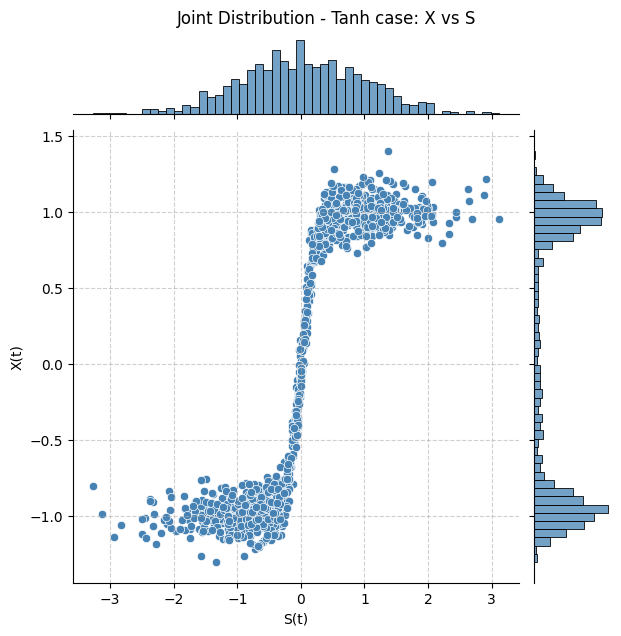

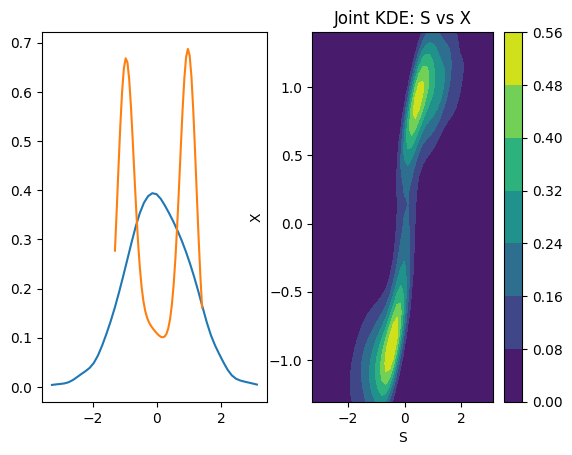

In [28]:
N = N_vec[-1]
data = nlib.generate_data(N, sigma_, f = f)


from scipy.stats import gaussian_kde
kde_s = gaussian_kde(data[:,0])
kde_x = gaussian_kde(data[:, 1])
kde_sx = gaussian_kde(data.T)


nlib.plot_joint_distribution_sns(data[:,0], data[:,1], title_string = "Tanh case: X vs S")

fig, axs = plt.subplots(nrows = 1, ncols = 2)
s_plot = np.linspace(np.min(data[:,0]), np.max(data[:, 0]))
x_plot = np.linspace(np.min(data[:,1]), np.max(data[:, 1]))

ax = axs[0]
ax.plot(s_plot, kde_s.pdf(s_plot))
ax.plot(x_plot, kde_x.pdf(x_plot))


ax = axs[1]


S, X = np.meshgrid(s_plot, x_plot)
positions = np.vstack([S.ravel(), X.ravel()])
Z = np.reshape(kde_sx(positions).T, S.shape)


ax = axs[1]
cf = ax.contourf(S, X, Z, cmap='viridis') # Using contourf for a filled contour plot
plt.colorbar(cf, ax=ax)                  # Add a colorbar to show density values

ax.set_xlabel('S')
ax.set_ylabel('X')
ax.set_title("Joint KDE: S vs X")

**Q:** why kde severely underestimates mi in this case?

## GAUSSIAN COPULA METHOD
Relies on the result
$$
mi(X:S) = - h(c)
$$
where c is the copula density function, and on the fact that $c$ is invariant under strictly monotonic transformations on both variables. 

**Input:** X, S two continuous random variables

**Algortihm:**

1. Compute the empiric marginal CDFs, $\hat{F}_S$ and $\hat{F}_X$
1. Transform each variable, independently, to a normal univariate gaussian

    $$
    S \rightarrow S' = \phi^{-1}(\hat{F}_S(S)) \\
    X \rightarrow X' = \phi^{-1}(\hat{F}_X(X)) \\
    $$
    $\phi^{-1}$: inverse cdf of a standard normal (mean $0$, std $1$).

2. Estimate $mi(X':S')$ assuming joint normality:

    $$
    mi(X':S') = - \frac{1}{2}\log_2(1 - \rho^2)
    $$

**Output:** $mi(X':S')= mi(X:S)$

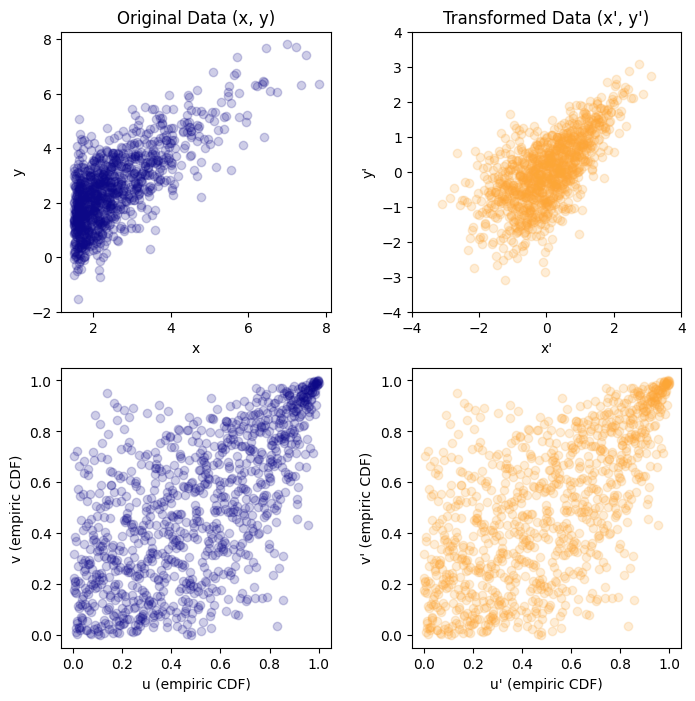

In [30]:
# Reproduction of the figures shown in the article

n = 1000
sigma_ = 1

x = scipy.stats.expon.rvs(1.5, size = n)
y = x + scipy.stats.norm.rvs(loc = 0, scale = sigma_, size = n)

data = np.vstack([x, y]).T

colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "original": colors[0],
    "transformed": colors[1]
}


fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8,8))
axs = axs.flatten()

# ---------------------------
# -----Original Data --------
# ---------------------------
color = color_dict["original"]
axs[0].set_title("Original Data (x, y)")
axs[0].scatter(x, y, color = color, alpha = 0.2)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

cdfx = nlib.get_empiric_cdf(x)
cdfy = nlib.get_empiric_cdf(y)

u = cdfx(x)
v = cdfy(y)

axs[2].scatter(u, v, color = color, alpha = 0.2, label = "copula density")
axs[2].set_xlabel("u (empiric CDF)")
axs[2].set_ylabel("v (empiric CDF)")

# ---------------------------
# ---- Transformed Data -----
# ---------------------------

color = color_dict["transformed"]

eps = 1e-15 # cap to prevent infinities in xprime, yprime
xprime = scipy.stats.norm.ppf(np.clip(u, eps, 1 - eps)) # ppf= percent point function (inverse cdf)
yprime = scipy.stats.norm.ppf(np.clip(v, eps, 1 - eps))

axs[1].set_title("Transformed Data (x', y')")
axs[1].scatter(xprime, yprime,color = color, alpha = 0.2, label = "data")
axs[1].set_xlabel("x'")
axs[1].set_ylabel("y'")
axs[1].set_xlim(-4, +4)
axs[1].set_ylim(-4, +4)

cdfxprime = nlib.get_empiric_cdf(xprime)
cdfyprime = nlib.get_empiric_cdf(yprime)

uprime = cdfxprime(xprime)
vprime = cdfyprime(yprime)

axs[3].scatter(uprime, vprime, color = color, alpha = 0.2, label = "data")
axs[3].set_xlabel("u' (empiric CDF)")
axs[3].set_ylabel("v' (empiric CDF)")


plt.subplots_adjust(wspace = 0.3)

In [32]:
# ------------- true mi -----------------
N_large = 10000
y_large = scipy.stats.expon.rvs(1.5, size = N_large) + sigma_ * scipy.stats.norm.rvs(size = N_large)
true_hy = nlib.estimate_entropy_kde(y_large)
mi_true = true_hy - nlib.entropy_gaussian(sigma_)
print(f"True mi(x:y)= {mi_true}")
# ---------------------------------------


print(f"Estimated mi(x:y)= {nlib.estimate_mi(data, method = "gc")}")

True mi(x:y)= 0.4353854738457765
Estimated mi(x:y)= 0.3954738147426562


In [35]:
N = 1000
sigma = 0.1
data = nlib.generate_data(N, sigma)

print(nlib.mi_gaussian_analytic(sigma**2))



dynamic_max = max(int(2 * np.sqrt(N)) , 50)
step = 2
bins = np.arange(10, dynamic_max, step)

print(nlib.estimate_mi(data, method='binning', bins = bins))
print(nlib.estimate_mi(data, method='kde'))
print(nlib.estimate_mi(data, method='gc'))
print(nlib.estimate_mi(data, method='gauss'))

3.3291057413758973
3.070195807999407
3.374445050914984
3.3158043010282916
3.35097009003666


## Comments



**What we estimate MI for:**
- MI between neural variable and an external signal
- MI between two neural variables
- Transfer entropy/Granger causality :: CMI between two neural variables

_NOTICE:_ The key idea is that MI should detect **any statistical dependence**. The main issue is how to estimate MI though. 



## Formulas



**Relations between the differential quantities:**

At difference with the discrete case, the differential entropy is not invariant under a monotonic transformation. 


- If X = f(S) with f monotonic, it holds that:

    $$
    h(X) = h(S) + \mathbb{E}\left[\ln |f'(S)|\right]
    $$

- If $X = f(S) + \sigma \cdot \eta$ with f monotonic (**Gaussian noisy channel**), it is not possible to compute analytically the entropy of X, except for a few special cases (gaussian S and linear f)

    $$
    h(X) = h(f(S) + \eta )  = \mathbf{?}
    $$

    Therefore, we need to resort to **numeric integration** to have a ground truth value for h(X).

.

.

.



Also, at difference with the discrete case, it is no longer true that if $X = f(S)$, then $h(X|S) = 0$. Instead, if $X= f(S)$ it holds that $h(X|S) = - \infty$.

To work with finite numbers, it is convenient to add some noise $X =  f(S) + \sigma \cdot \eta$, so that $h(X|S)$ is the differential entropy of a normal variable, 

$$
h(X|S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2]
$$

.

.

.


Putting everything together, the differential mutual information will be given by:

$$
mi(X:S) = h(X) - h(X|S) \simeq \left[ h(X)^{num} \right] - \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2] \geq 0
$$

where $h(X)^{num}$ is an estimate obtained through numeric integration or montecarlo.


$mi(X:S)\geq 0$ always and $mi(X:S)\rightarrow +\infty$ for $\sigma \rightarrow 0$ (deterministic case). 


This actually makes sense, although can be a little confusing:

*Because S is a continuous variable, it technically contains an infinite amount of information (it takes an infinite number of decimal places to specify its exact value). If X=f(S) and f is monotonic, then knowing S tells you X with infinite precision. Therefore, the information they share is infinite.*

-------------------------

**Channel capacity of a Gaussian channel**

Since we are generating the response variable adding a gaussian white noise, $X = f(S) + \sigma \cdot \eta$, we are inside the framework of a gaussian noisy channel. The differential mutual information between X and S depends on i) the distribution of the source, ii) the functional form of f, but in any case it is upper bounded by the channel capacity.

.

.


Restricting to source variables $Z=f(S)$ with $E[Z] = 0, E[z^2] \leq v^2$


$$
0 \leq mi(X:Z) \leq C = max_{p(Z)} \left\{mi(X:Z)\right\} = \frac{1}{2} \log_2 [1 + \left(\frac{v}{\sigma}\right)^2]
$$

In particular:

- if S is normally distributed and $f$ is a linear function, then  also Z is normally distributed, and the mi between X and Z ($\equiv mi(X:S)$) is the channel capacity.

-------------------------

*Binning*

We are interested in estimating the *differential mutual information (mi)* between the continuous r.v.s. X and S. The *binning* method makes use of this fact:





If X, S are the continuous r.v.s and $X_\epsilon, S_\epsilon$ are their discretized (binned) versions,

$$
lim_{\epsilon \rightarrow 0^+} MI(X_{\epsilon}: S_{\epsilon}) = mi(X, S)
$$



-------------------
**Relations between the discretized quantities:**

 - If X is a deterministic function of S, $H(X_\epsilon|S_\epsilon) = 0$. Hence:

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(X_{\epsilon}) - H(X_\epsilon|S_\epsilon) \equiv  H(X_{\epsilon})
    $$

    Entropies of the response X and the source S are linked by the *data processing inequality*, which states that:

    $$
    \text{if} \quad X = f(S), \quad \text{then} \quad H(X) \leq H(S)
    $$


    In particular, if $f$ is a **bijective** function, $H(X) \equiv H(S)$. In this case, therefore, 

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(S_{\epsilon}).
    $$


-------------------------
Differential entropy of a gaussian r.v.

$$
h(S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma_S^2]
$$

$$
H(S_\epsilon) = h(S) + \log_2\left(\frac{1}{\epsilon}\right) + \mathcal{O}(\epsilon)
$$

-------------------------
